<a href="https://colab.research.google.com/github/MuhammadYusril568/Muhammad-Yusril/blob/main/Logistik_Regression_Tugas_2_Muhammad_Yusril.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install reportlab

In [ ]:
import pandas as pd

# ambil dataset asli
url = "https://raw.githubusercontent.com/microsoft/ML-For-Beginners/main/2-Regression/data/US-pumpkins.csv"

full_pumpkins = pd.read_csv(url)

full_pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [ ]:
columns_to_select = ['City Name','Package','Variety', 'Origin','Item Size', 'Color']
pumpkins = full_pumpkins.loc[:, columns_to_select]

pumpkins.dropna(inplace=True)

pumpkins.head()

,City Name,Package,Variety,Origin,Item Size,Color
2,BALTIMORE,24 inch bins,HOWDEN TYPE,DELAWARE,med,ORANGE
3,BALTIMORE,24 inch bins,HOWDEN TYPE,VIRGINIA,med,ORANGE
4,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
5,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
6,BALTIMORE,36 inch bins,HOWDEN TYPE,MARYLAND,med,ORANGE


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in pumpkins.columns:
    pumpkins[column] = le.fit_transform(pumpkins[column])

In [ ]:
X = pumpkins[['Package','Variety','Origin','Item Size']]
y = pumpkins['Color']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [ ]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0]


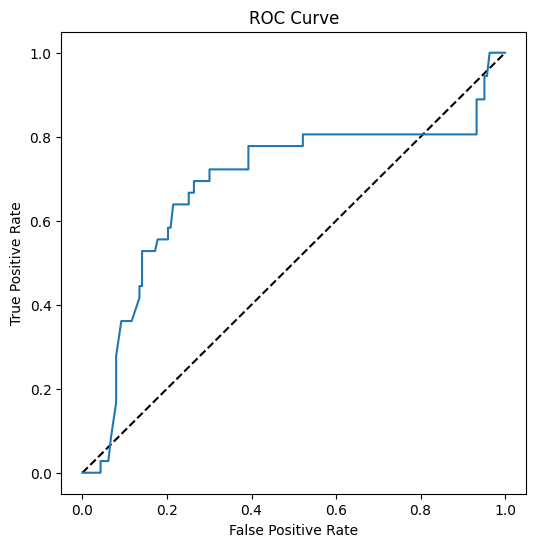

In [ ]:

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

plt.figure(figsize=(6,6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.8040201005025126


In [ ]:

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))


from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

[[160   3]
 [ 36   0]]
              precision    recall  f1-score   support

           0       0.82      0.98      0.89       163
           1       0.00      0.00      0.00        36

    accuracy                           0.80       199
   macro avg       0.41      0.49      0.45       199
weighted avg       0.67      0.80      0.73       199



In [ ]:
!pip install reportlab

from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# hitung ulang biar pasti ada
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# buat pdf
doc = SimpleDocTemplate("/content/laporan_logreg.pdf")
styles = getSampleStyleSheet()

content = []

# judul
content.append(Paragraph("LAPORAN LOGISTIC REGRESSION", styles['Title']))
content.append(Spacer(1, 12))

# hasil
content.append(Paragraph(f"Akurasi: {acc}", styles['Normal']))
content.append(Spacer(1, 10))

content.append(Paragraph(f"Confusion Matrix: {cm}", styles['Normal']))
content.append(Spacer(1, 10))

content.append(Paragraph("Classification Report:", styles['Normal']))
content.append(Paragraph(f"<pre>{report}</pre>", styles['Normal']))

# build
doc.build(content)

print("PDF siap!")

PDF siap!


In [ ]:
from google.colab import files
files.download("/content/laporan_logreg.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>